# 📊 Notebook 1: Data Generation & Exploration
Understand the structure of logged bandit data before running any estimators.

In [5]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 110


## 1.1 Generate a Contextual Bandit Dataset

In [6]:
from data.data_generator import ContextualBanditGenerator, SequentialBanditGenerator

gen = ContextualBanditGenerator(n_features=10, n_actions=5, seed=42)
data = gen.generate(n=5000, logging_temp=1.5, target_temp=0.5)
print(data.summary())


BanditDataset  n=5000  n_actions=5
  Reward       mean=2.0974  std=2.2500
  Log-prob     mean=0.4547  min=0.0008
  IPS weights  mean=1.04  max=171.34  ESS=184.6


## 1.2 Reward & Propensity Distributions

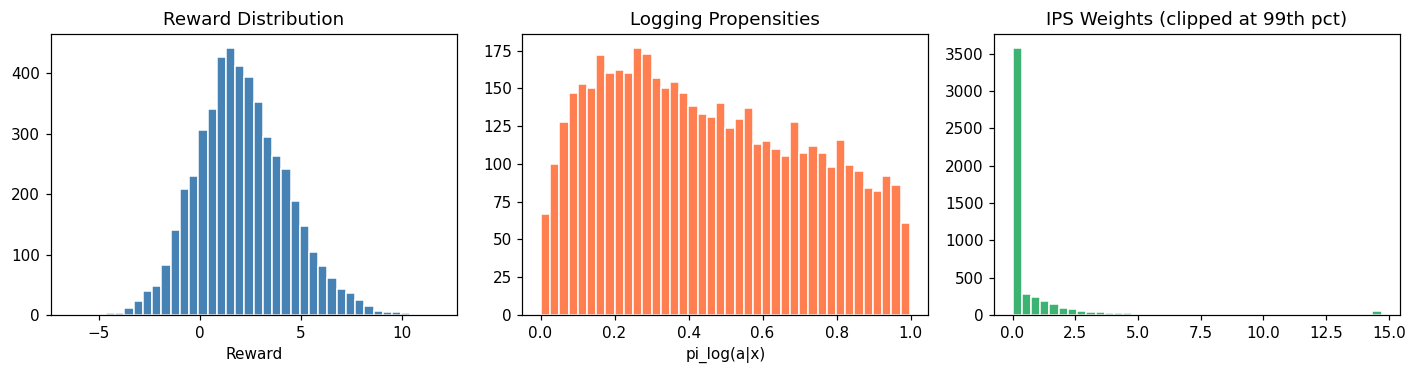

ESS: 184.6 / 5000 (3.7%)


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
axes[0].hist(data.reward, bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Reward Distribution'); axes[0].set_xlabel('Reward')
axes[1].hist(data.logging_prob, bins=40, color='coral', edgecolor='white')
axes[1].set_title('Logging Propensities'); axes[1].set_xlabel('pi_log(a|x)')
iw = data.importance_weights
axes[2].hist(np.clip(iw, 0, np.percentile(iw, 99)), bins=40, color='mediumseagreen', edgecolor='white')
axes[2].set_title('IPS Weights (clipped at 99th pct)')
plt.tight_layout(); plt.show()
print(f'ESS: {data._ess(iw):.1f} / {data.n} ({100*data._ess(iw)/data.n:.1f}%)')


## 1.3 Distribution Shift

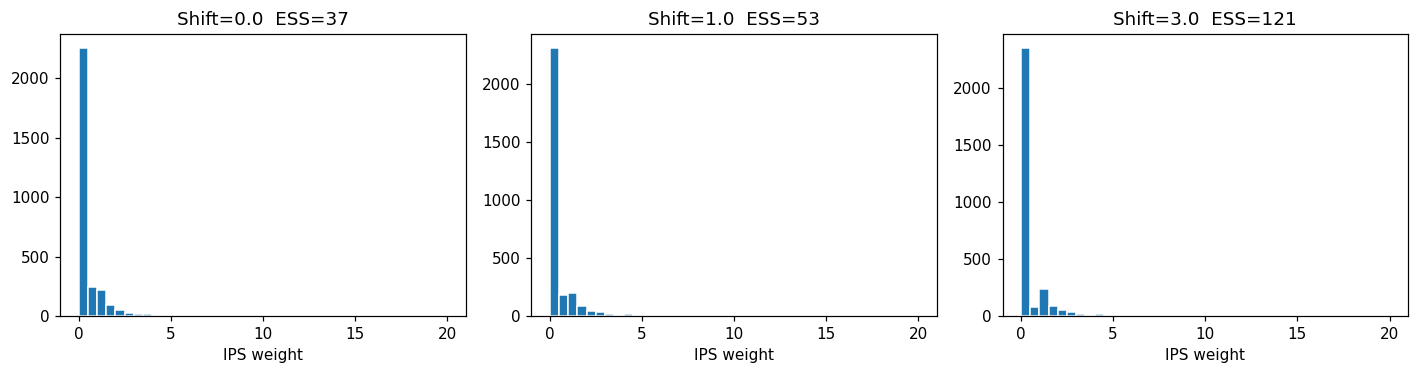

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, shift in zip(axes, [0.0, 1.0, 3.0]):
    d = gen.generate(n=3000, shift=shift)
    iw = d.importance_weights
    ax.hist(np.clip(iw, 0, 20), bins=40, edgecolor='white')
    ax.set_title(f'Shift={shift}  ESS={d._ess(iw):.0f}')
    ax.set_xlabel('IPS weight')
plt.tight_layout(); plt.show()


## 1.4 Sequential Data

BanditDataset  n=3000  n_actions=3
  Reward       mean=-0.1644  std=0.6291
  Log-prob     mean=0.3939  min=0.0477
  IPS weights  mean=0.94  max=8.79  ESS=1486.4


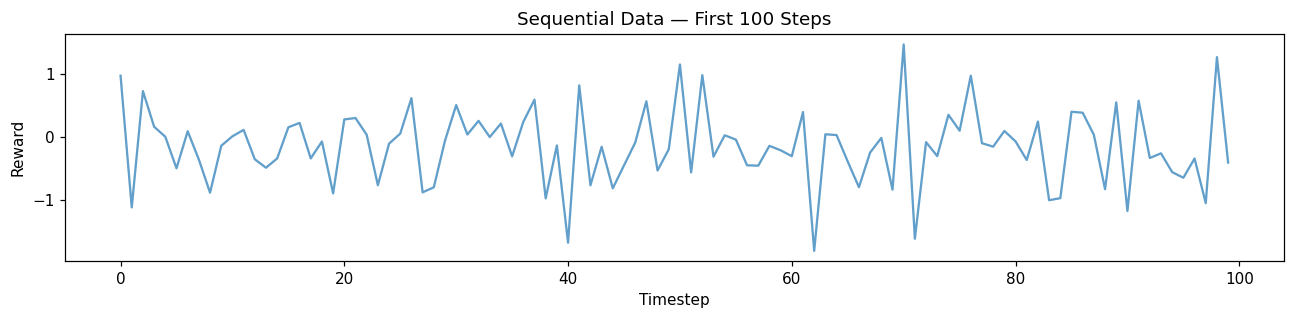

In [9]:
seq_gen = SequentialBanditGenerator(state_dim=6, n_actions=3, horizon=10, seed=42)
seq_data = seq_gen.generate(n_episodes=300)
print(seq_data.summary())
plt.figure(figsize=(12, 3))
plt.plot(seq_data.timestamp[:100], seq_data.reward[:100], alpha=0.7)
plt.xlabel('Timestep'); plt.ylabel('Reward'); plt.title('Sequential Data — First 100 Steps')
plt.tight_layout(); plt.show()


## 1.5 Sparse Rewards

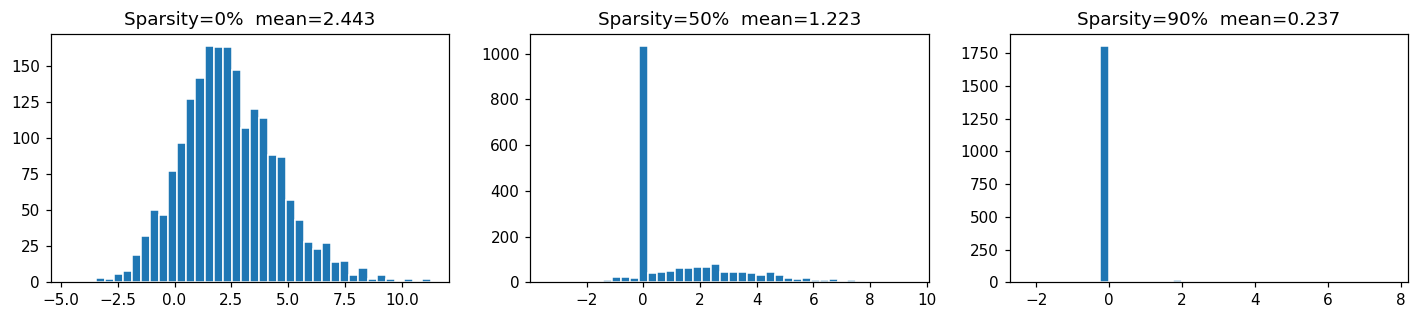

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3))
for ax, sparsity in zip(axes, [0.0, 0.5, 0.9]):
    d = gen.generate(n=2000, sparse_reward_frac=sparsity)
    ax.hist(d.reward, bins=40, edgecolor='white')
    ax.set_title(f'Sparsity={sparsity:.0%}  mean={d.reward.mean():.3f}')
plt.tight_layout(); plt.show()
